### Counting and Displaying Class Distribution from Filenames in the Dataset

In [1]:
import os
import re
from collections import Counter

# Patterns for extracting labels
patterns = [r"fs\d+_(\w+)_roi", r"training_(\w+)_roi"]

# Function to extract label from a filename
def extract_label(filename):
    for pattern in patterns:
        match = re.search(pattern, filename)
        if match:
            return match.group(1)
    return None

# Function to count classes in the dataset
def count_classes(image_dir):
    class_counter = Counter()

    # Traverse all files in the directory
    for root, _, files in os.walk(image_dir):
        for file in files:
            label = extract_label(file)
            if label:
                class_counter[label] += 1

    return class_counter

# Path to the directory containing images
image_dir = r"E:\\Studium_E\\ML\\Plankton_Converted\\Converted"

# Count classes
class_counts = count_classes(image_dir)

# Print the number of classes and their distribution
print(f"Number of classes: {len(class_counts)}")
print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


Number of classes: 26
Class distribution:
appendicularia_house: 2372
appendicularia: 1023
bipinnaria: 663
blurry: 3844
copepods: 5692
diatoms: 11887
eggs: 501
larvae: 298
malacostraca: 601
medusae: 714
mnemiopsis: 1034
noctiluca: 5059
pluteus: 28974
polychaeta: 1358
rod: 3185
snow: 143295
unknown: 1750
worms: 4165
zoea_larvae: 386
actinotrocha: 264
pilidium: 244
veliger_larvae: 378
amphipods: 288
echinodermata: 119
phaeocystis: 267
pteropods: 701


---
### Organizing Images into Class Folders Based on Filename Patterns


In [ ]:
import os
import re
import shutil

patterns = [
    r"fs\d+_(\w+)_roi",  
    r"training_(\w+)_roi",  
]

source_path = r"E:\\Studium_E\\ML\\Plankton_Converted\\Converted"
target_path = r"E:\\Studium_E\\ML\\Divided_Plancton"

os.makedirs(target_path, exist_ok=True)

def get_class_name(filename):
    """Extract class name from the filename using the patterns."""
    for pattern in patterns:
        match = re.search(pattern, filename)
        if match:
            return match.group(1)
    return None

def organize_images():
    """Organize images into folders based on their class names."""
    for root, _, files in os.walk(source_path):
        for file in files:
            class_name = get_class_name(file)
            if class_name:
                class_folder = os.path.join(target_path, class_name)
                os.makedirs(class_folder, exist_ok=True)


                source_file = os.path.join(root, file)
                target_file = os.path.join(class_folder, file)
                shutil.move(source_file, target_file)

                print(f"Moved: {source_file} -> {target_file}")
            else:
                print(f"Skipped: {file} (No matching class)")

if __name__ == "__main__":
    organize_images()

---
### Creating a Reduced Dataset by Randomly Sampling Images from Each Class


In [4]:
import os
import random
import shutil

# Parameters
INPUT_DIR = "E:/Studium_E/ML/Divided_Plancton"  # Original dataset directory
OUTPUT_DIR = "E:/Studium_E/ML/Mini_Plancton"  # Directory to save reduced dataset
IMAGES_PER_CLASS = 100  # Number of images per class

def create_reduced_dataset(input_dir, output_dir, images_per_class):
    os.makedirs(output_dir, exist_ok=True)

    # Iterate over each class folder
    for class_folder in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_folder)

        if os.path.isdir(class_path):
            # Get all images in the current class folder
            all_images = [
                os.path.join(class_path, img)
                for img in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, img))
            ]

            # Randomly sample the desired number of images
            sampled_images = random.sample(all_images, min(images_per_class, len(all_images)))

            # Create output directory for the current class
            output_class_dir = os.path.join(output_dir, class_folder)
            os.makedirs(output_class_dir, exist_ok=True)

            # Copy sampled images to the output directory
            for img_path in sampled_images:
                shutil.copy(img_path, output_class_dir)

            print(f"Processed class '{class_folder}' with {len(sampled_images)} images.")

create_reduced_dataset(INPUT_DIR, OUTPUT_DIR, IMAGES_PER_CLASS)


Processed class 'actinotrocha' with 100 images.
Processed class 'amphipods' with 100 images.
Processed class 'appendicularia' with 100 images.
Processed class 'appendicularia_house' with 100 images.
Processed class 'bipinnaria' with 100 images.
Processed class 'blurry' with 100 images.
Processed class 'copepods' with 100 images.
Processed class 'diatoms' with 100 images.
Processed class 'echinodermata' with 100 images.
Processed class 'eggs' with 100 images.
Processed class 'larvae' with 100 images.
Processed class 'malacostraca' with 100 images.
Processed class 'medusae' with 100 images.
Processed class 'mnemiopsis' with 100 images.
Processed class 'noctiluca' with 100 images.
Processed class 'phaeocystis' with 100 images.
Processed class 'pilidium' with 100 images.
Processed class 'pluteus' with 100 images.
Processed class 'polychaeta' with 100 images.
Processed class 'pteropods' with 100 images.
Processed class 'rod' with 100 images.
Processed class 'snow' with 100 images.
Processed

---
### Loading and Preparing the Dataset for Training with TensorFlow

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# Parameters
IMG_SIZE = (128, 128)  # Image dimensions
BATCH_SIZE = 32
EPOCHS = 10
DATASET_DIR = "E:/Studium_E/ML/Divided_Plancton"  # Path to the reduced dataset

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",  # Labels are inferred from folder names
    label_mode="int",   # Class indices as integers
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # Use 20% for validation
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 219062 files belonging to 26 classes.
Using 175250 files for training.
Found 219062 files belonging to 26 classes.
Using 43812 files for validation.


### Building a Convolutional Neural Network with MobileNetV2 as a Base Model for Image Classification


In [2]:
# Load the base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),  # RGB input
    include_top=False,  # Exclude the final classification layer
    weights='imagenet'  # Pre-trained on ImageNet
)

# Freeze the base model
base_model.trainable = False

# Add custom classification layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(26, activation='softmax')  # 26 classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Training the Model with the Prepared Dataset


In [3]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 1092s 199ms/step - accuracy: 0.7394 - loss: 0.9247 - val_accuracy: 0.8080 - val_loss: 0.6402
Epoch 2/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 703s 128ms/step - accuracy: 0.7920 - loss: 0.7036 - val_accuracy: 0.8065 - val_loss: 0.6350
Epoch 3/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 708s 129ms/step - accuracy: 0.8048 - loss: 0.6653 - val_accuracy: 0.8191 - val_loss: 0.5961
Epoch 4/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 707s 129ms/step - accuracy: 0.8090 - loss: 0.6455 - val_accuracy: 0.8166 - val_loss: 0.6006
Epoch 5/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 702s 128ms/step - accuracy: 0.8107 - loss: 0.6347 - val_accuracy: 0.8289 - val_loss: 0.5684
Epoch 6/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 690s 126ms/step - accuracy: 0.8160 - loss: 0.6207 - val_accuracy: 0.8266 - val_loss: 0.5730
Epoch 7/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 698s 127ms/step - accuracy: 0.8180 - loss: 0.6144 - val_accuracy: 0.8269 - val_loss: 0.5757
Epoch 8/10
5477/5477 ━━━━━━━━━━━━━━━━━━━━ 686s 125ms/step - a

### Saving the Model and Evaluating Performance on the Validation Set


In [4]:
# Save the model
model.save("plankton_classifier_new.h5")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy:.2f}")


1370/1370 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - accuracy: 0.8308 - loss: 0.5643
Validation Accuracy: 0.83


### Plotting Training and Validation Accuracy/Loss Curves


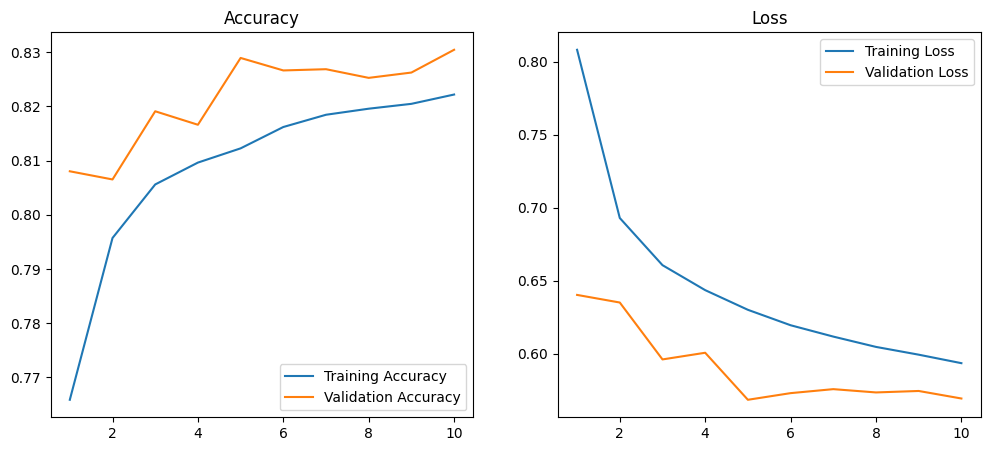

In [5]:
import matplotlib.pyplot as plt

# Plot training history
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

plot_training_history(history)


---
### Loading and Inspecting the Dataset 

In [5]:
import tensorflow as tf

# Parameters
data_dir = "E:/Studium_E/ML/Mini_Plancton"
batch_size = 32
image_size = (128, 128)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

# Access class names from the train dataset
class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:", class_names)


Found 2600 files belonging to 26 classes.
Using 2080 files for training.
Found 2600 files belonging to 26 classes.
Using 520 files for validation.
Number of classes: 26
Class names: ['actinotrocha', 'amphipods', 'appendicularia', 'appendicularia_house', 'bipinnaria', 'blurry', 'copepods', 'diatoms', 'echinodermata', 'eggs', 'larvae', 'malacostraca', 'medusae', 'mnemiopsis', 'noctiluca', 'phaeocystis', 'pilidium', 'pluteus', 'polychaeta', 'pteropods', 'rod', 'snow', 'unknown', 'veliger_larvae', 'worms', 'zoea_larvae']


---
### Defining and Training a Simple Custom CNN Model

In [33]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Define a simple custom CNN
def create_custom_cnn(input_shape, num_classes):
    model = Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Get the input shape and number of classes
input_shape = (128, 128, 3)

# Create and train the model
cnn_model = create_custom_cnn(input_shape, num_classes)
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20


c:\Users\haru\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.0770 - loss: 3.2086 - val_accuracy: 0.2885 - val_loss: 2.7180
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.2522 - loss: 2.6792 - val_accuracy: 0.3327 - val_loss: 2.3906
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.3303 - loss: 2.3326 - val_accuracy: 0.4000 - val_loss: 2.2250
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.3927 - loss: 2.0935 - val_accuracy: 0.4231 - val_loss: 2.1041
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.4460 - loss: 1.8586 - val_accuracy: 0.4692 - val_loss: 1.9386
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.5097 - loss: 1.6484 - val_accuracy: 0.4788 - val_loss: 1.8903
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.5549 - loss: 1.4662 - val_accuracy: 0.4923 - val_loss: 1.8975
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.6132 - loss: 1.2385 - val_accuracy: 0.5038 - v

### Plotting Training and Validation Accuracy/Loss for the CNN Model


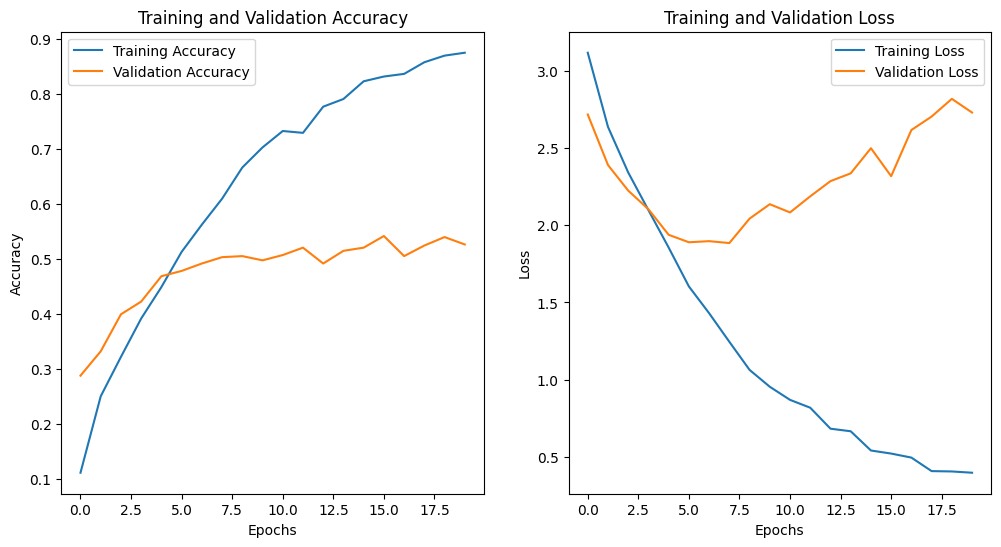

In [34]:
import matplotlib.pyplot as plt

# For deep learning models like CNN, VGG16, etc.
def plot_accuracy_loss(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='best')
    plt.show()

plot_accuracy_loss(cnn_model.history)

### Plotting ROC Curve and AUC for Multi-Class Classification


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


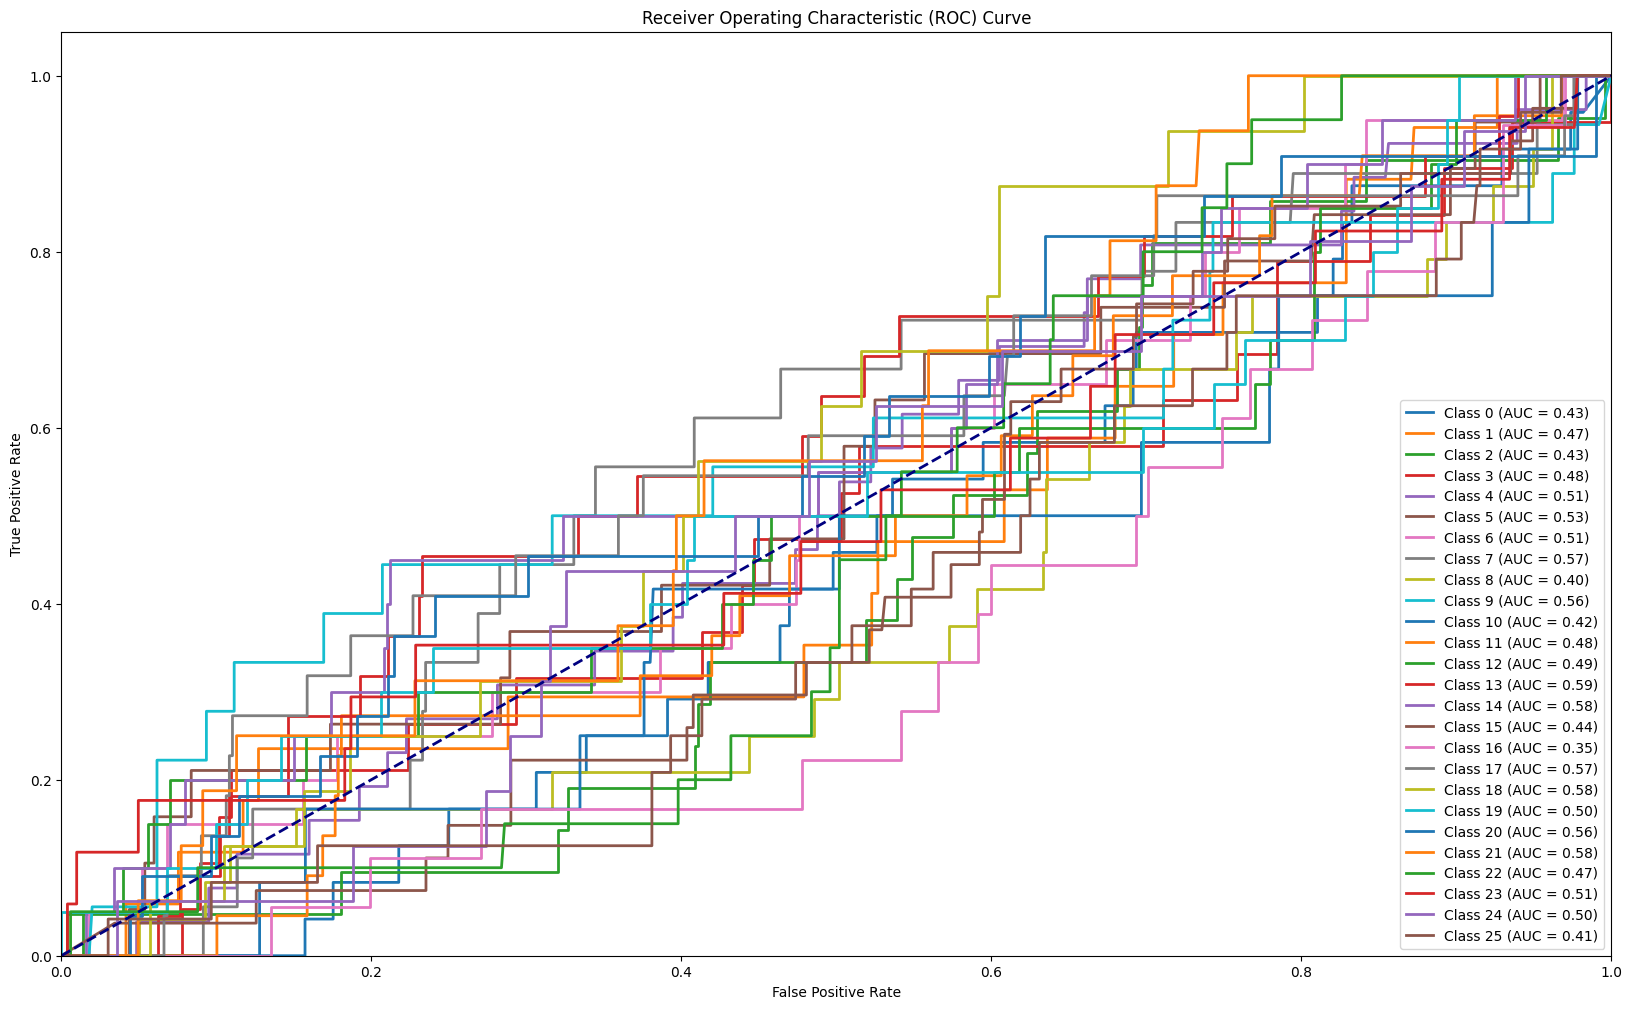

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_roc_curve(model, val_ds, num_classes):
    # Get predicted probabilities for each class
    y_pred = model.predict(val_ds)
    
    # Binarize the labels for multi-class classification
    y_val = np.concatenate([y for x, y in val_ds], axis=0)
    y_val_bin = label_binarize(y_val, classes=[i for i in range(num_classes)])
    
    # Compute ROC curve and AUC for each class
    plt.figure(figsize=(20, 12))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')
    
    # Plot the ROC curve
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()


plot_roc_curve(cnn_model, val_ds, num_classes)

### Plotting Precision-Recall Curve


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


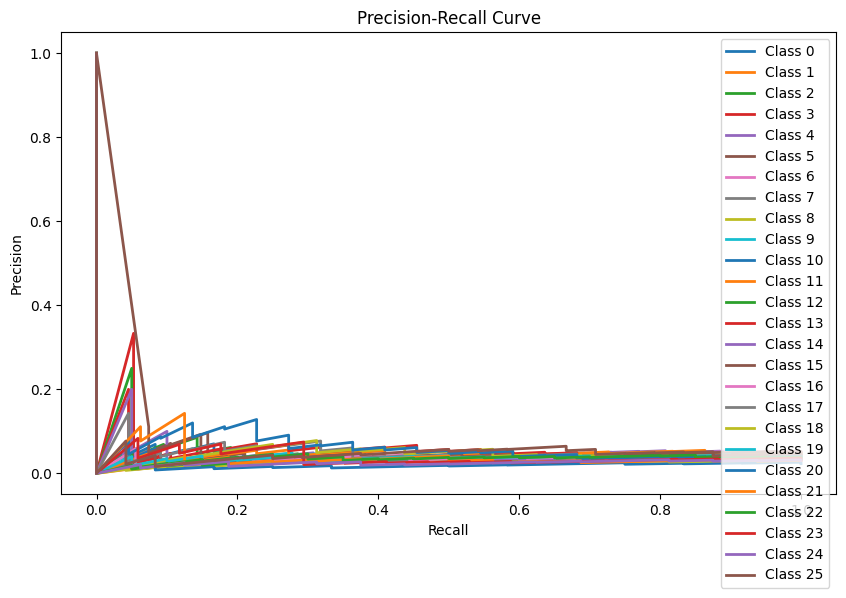

In [47]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

def plot_precision_recall_curve(model, val_ds, num_classes):
    # Get predicted probabilities for each class
    y_pred = model.predict(val_ds)
    
    # Binarize the labels for multi-class classification
    y_val = np.concatenate([y for x, y in val_ds], axis=0)  # Get the true labels from the validation dataset
    y_val_bin = label_binarize(y_val, classes=[i for i in range(num_classes)])
    
    plt.figure(figsize=(10, 6))
    
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_pred[:, i])
        plt.plot(recall, precision, lw=2, label=f'Class {i}')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='best')
    plt.show()

plot_precision_recall_curve(cnn_model, val_ds, num_classes)

### Plotting Class-wise Accuracy


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


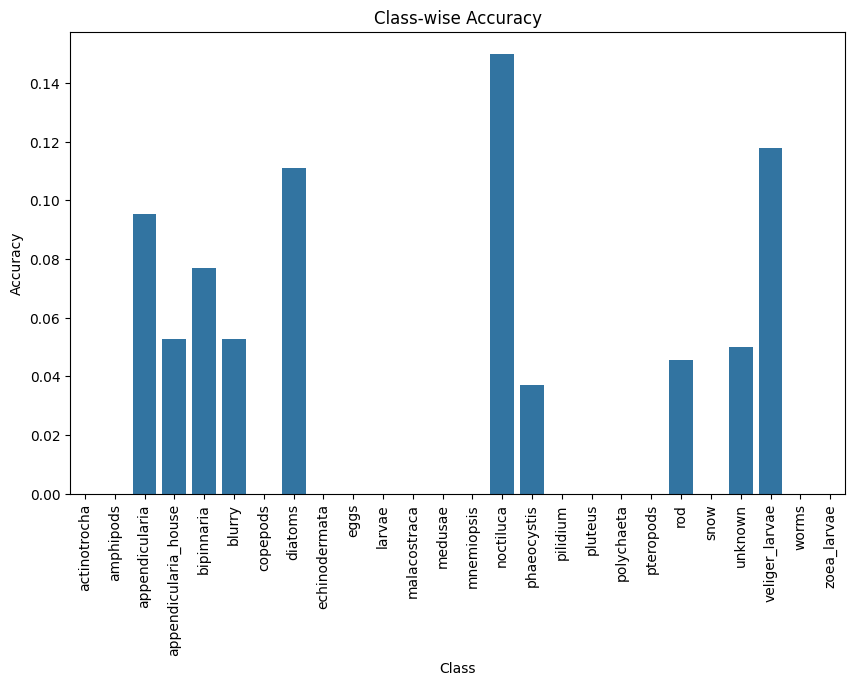

In [48]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_classwise_accuracy(model, val_ds, class_names):
    # Predict the classes
    y_pred = model.predict(val_ds)
    
    # If the output is probabilities, use argmax to get the predicted class
    if y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)

    # Get true labels
    y_val = np.concatenate([y for x, y in val_ds], axis=0)
    
    cm = confusion_matrix(y_val, y_pred)  # Compute confusion matrix
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot class-wise accuracy
    classwise_accuracy = np.diagonal(cm_normalized)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=class_names, y=classwise_accuracy)
    plt.title('Class-wise Accuracy')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=90)
    plt.show()

plot_classwise_accuracy(cnn_model, val_ds, train_ds.class_names)


---
### Extracting Features from a Pre-trained Model (e.g., VGG16)


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, EfficientNetB0
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

# Load dataset
data_dir = "E:/Studium_E/ML/Mini_Plancton"
image_size = (128, 128)
batch_size = 32

# Load dataset using image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

# Use pre-trained model to extract features (e.g., VGG16)
def extract_features(model, dataset):
    features = []
    labels = []
    for images, label_batch in dataset:
        feature_batch = model.predict(images)
        features.append(feature_batch)
        labels.append(label_batch.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

# Choose a pre-trained model, e.g., VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze the model to use as feature extractor
feature_extractor = tf.keras.Sequential([base_model, tf.keras.layers.GlobalAveragePooling2D()])

# Extract features from the training and validation datasets
X_train, y_train = extract_features(feature_extractor, train_ds)
X_val, y_val = extract_features(feature_extractor, val_ds)

print("Feature shape:", X_train.shape)


Found 2600 files belonging to 26 classes.
Using 2080 files for training.
Found 2600 files belonging to 26 classes.
Using 520 files for validation.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━

---
### Training a Decision Tree Classifier and Plotting the Confusion Matrix


Decision Tree Accuracy: 0.4096153846153846
              precision    recall  f1-score   support

           0       0.32      0.29      0.30        24
           1       0.11      0.12      0.11        17
           2       0.12      0.10      0.11        21
           3       0.28      0.37      0.32        19
           4       0.43      0.35      0.38        26
           5       0.30      0.32      0.31        19
           6       0.32      0.30      0.31        20
           7       0.50      0.33      0.40        18
           8       0.60      0.50      0.55        24
           9       0.70      0.89      0.78        18
          10       0.57      0.67      0.62        12
          11       0.17      0.14      0.15        22
          12       0.36      0.40      0.38        20
          13       0.68      0.59      0.63        22
          14       0.55      0.60      0.57        20
          15       0.79      0.70      0.75        27
          16       0.36      0.50     

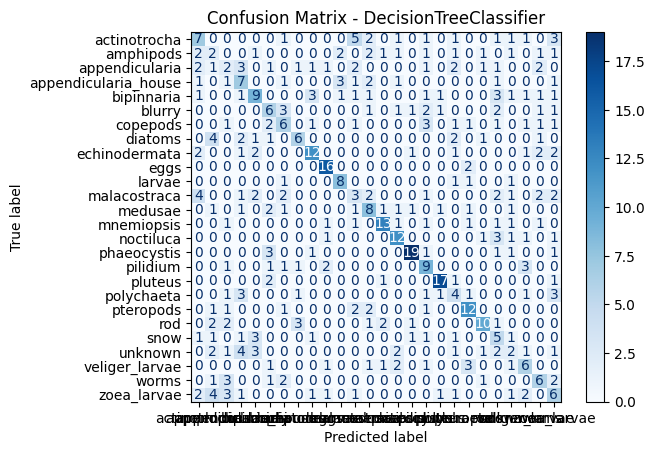

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on validation set
y_pred_dt = dt_model.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_val, y_val, class_names):
    # Predict class labels
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

plot_confusion_matrix(dt_model, X_val, y_val, train_ds.class_names)

### Plotting Normalized Class-wise Accuracy using Confusion Matrix


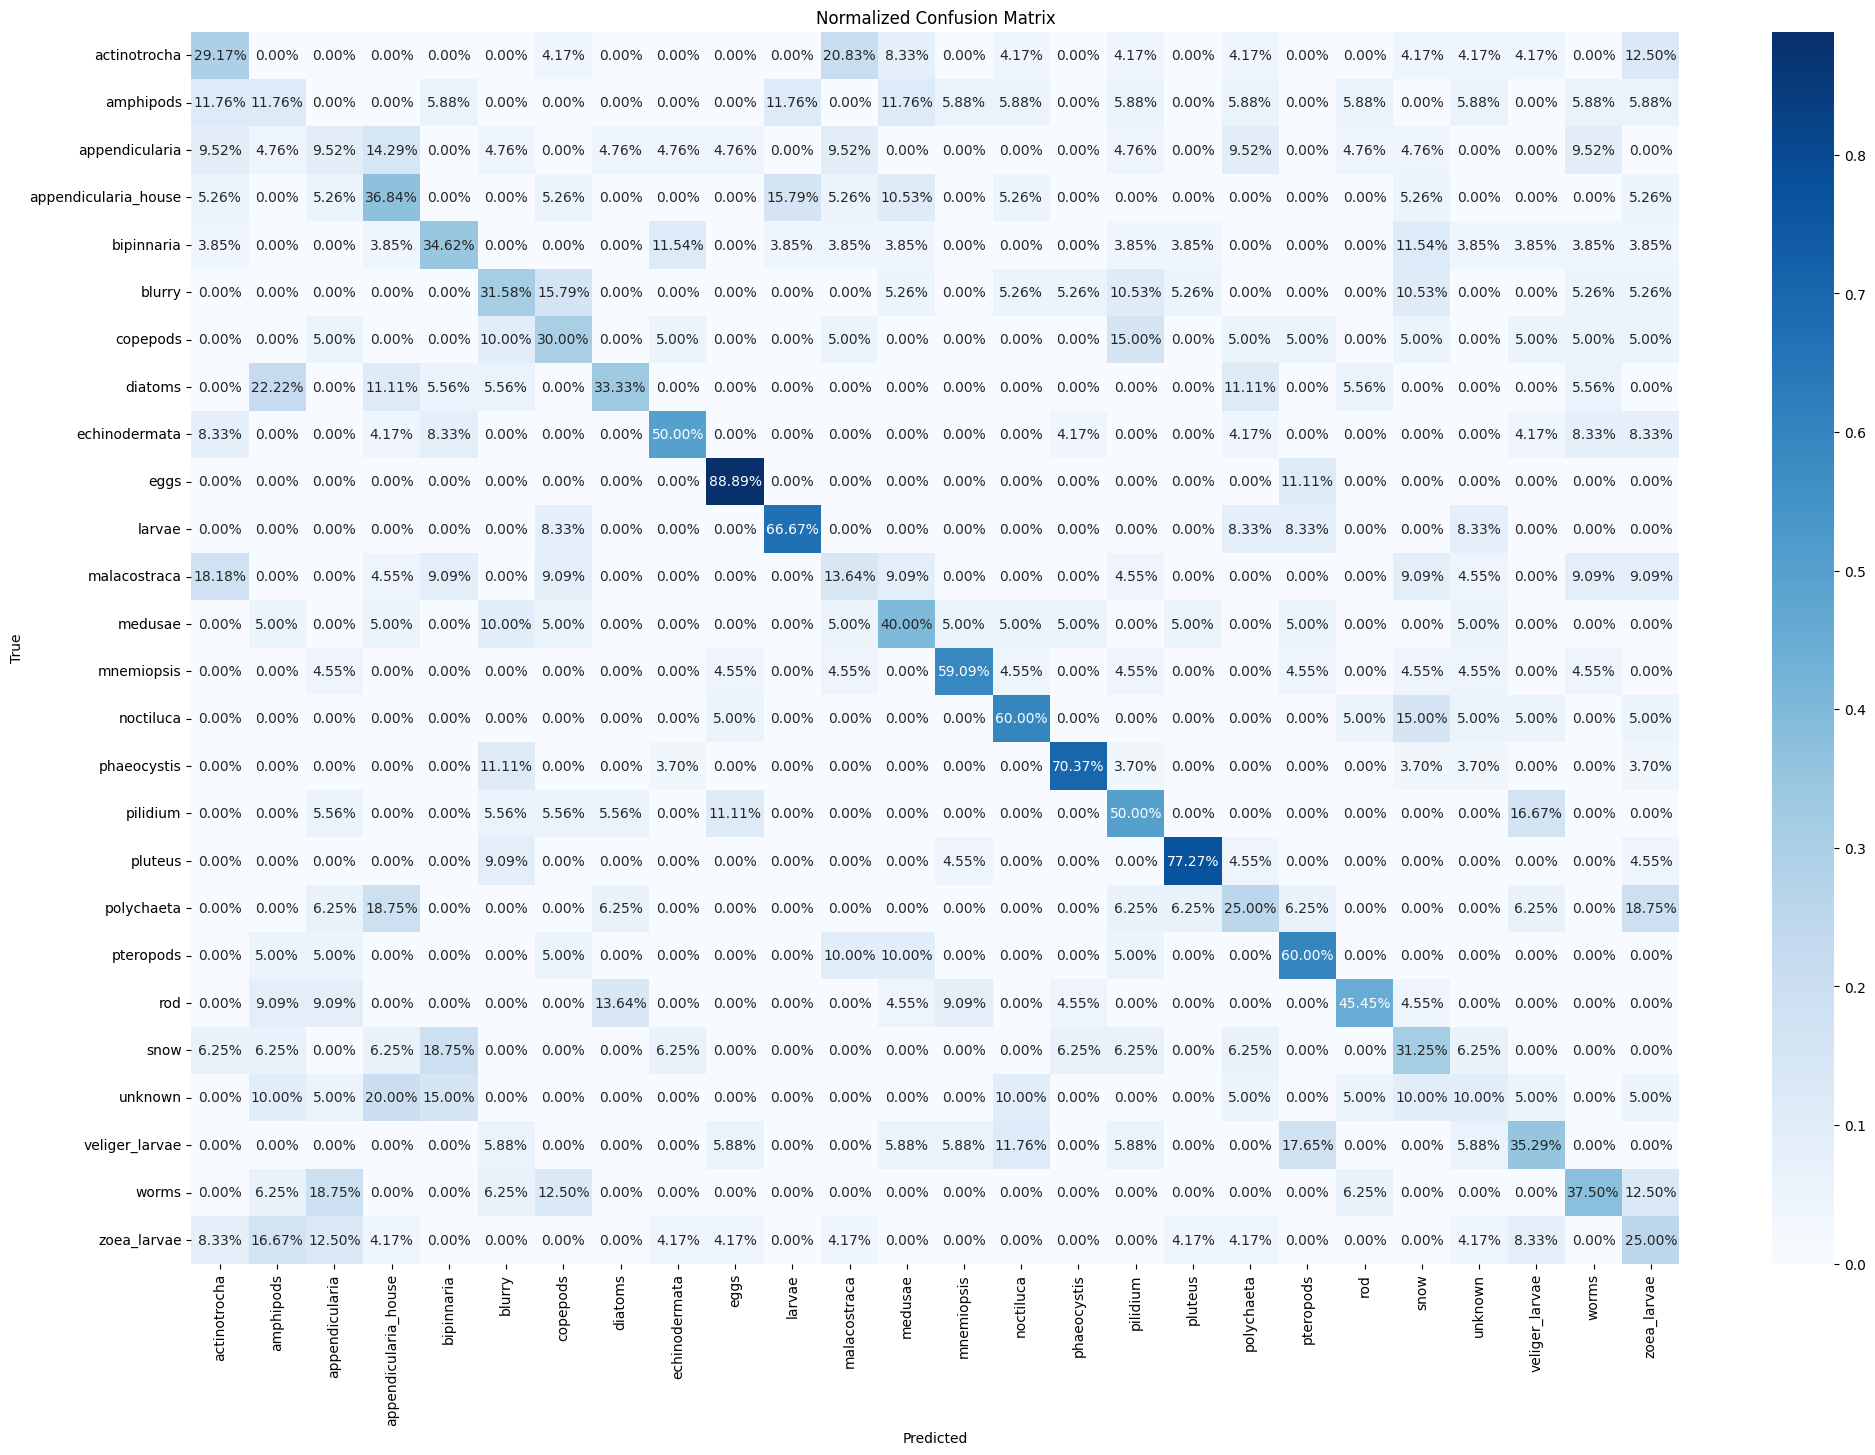

In [30]:
import seaborn as sns

def plot_classwise_accuracy(y_true, y_pred, class_names):
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the normalized confusion matrix
    plt.figure(figsize=(24, 16))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_classwise_accuracy(y_val, y_pred_dt, train_ds.class_names)

---
### Training a Random Forest Classifier and Plotting the Confusion Matrix


Random Forest Accuracy: 0.6692307692307692
              precision    recall  f1-score   support

           0       0.69      0.75      0.72        24
           1       0.48      0.65      0.55        17
           2       0.55      0.52      0.54        21
           3       0.40      0.53      0.45        19
           4       0.94      0.58      0.71        26
           5       0.46      0.63      0.53        19
           6       0.52      0.55      0.54        20
           7       0.83      0.83      0.83        18
           8       0.79      0.79      0.79        24
           9       0.90      1.00      0.95        18
          10       1.00      0.58      0.74        12
          11       0.43      0.27      0.33        22
          12       0.89      0.40      0.55        20
          13       0.87      0.91      0.89        22
          14       0.53      0.80      0.64        20
          15       0.96      0.89      0.92        27
          16       0.58      0.78     

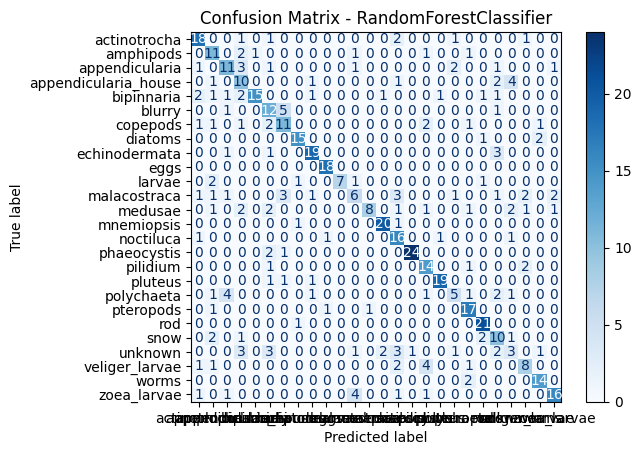

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_rf = rf_model.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_val, y_val, class_names):
    # Predict class labels
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

plot_confusion_matrix(rf_model, X_val, y_val, train_ds.class_names)

### Plotting Normalized Class-wise Accuracy for Random Forest using Confusion Matrix


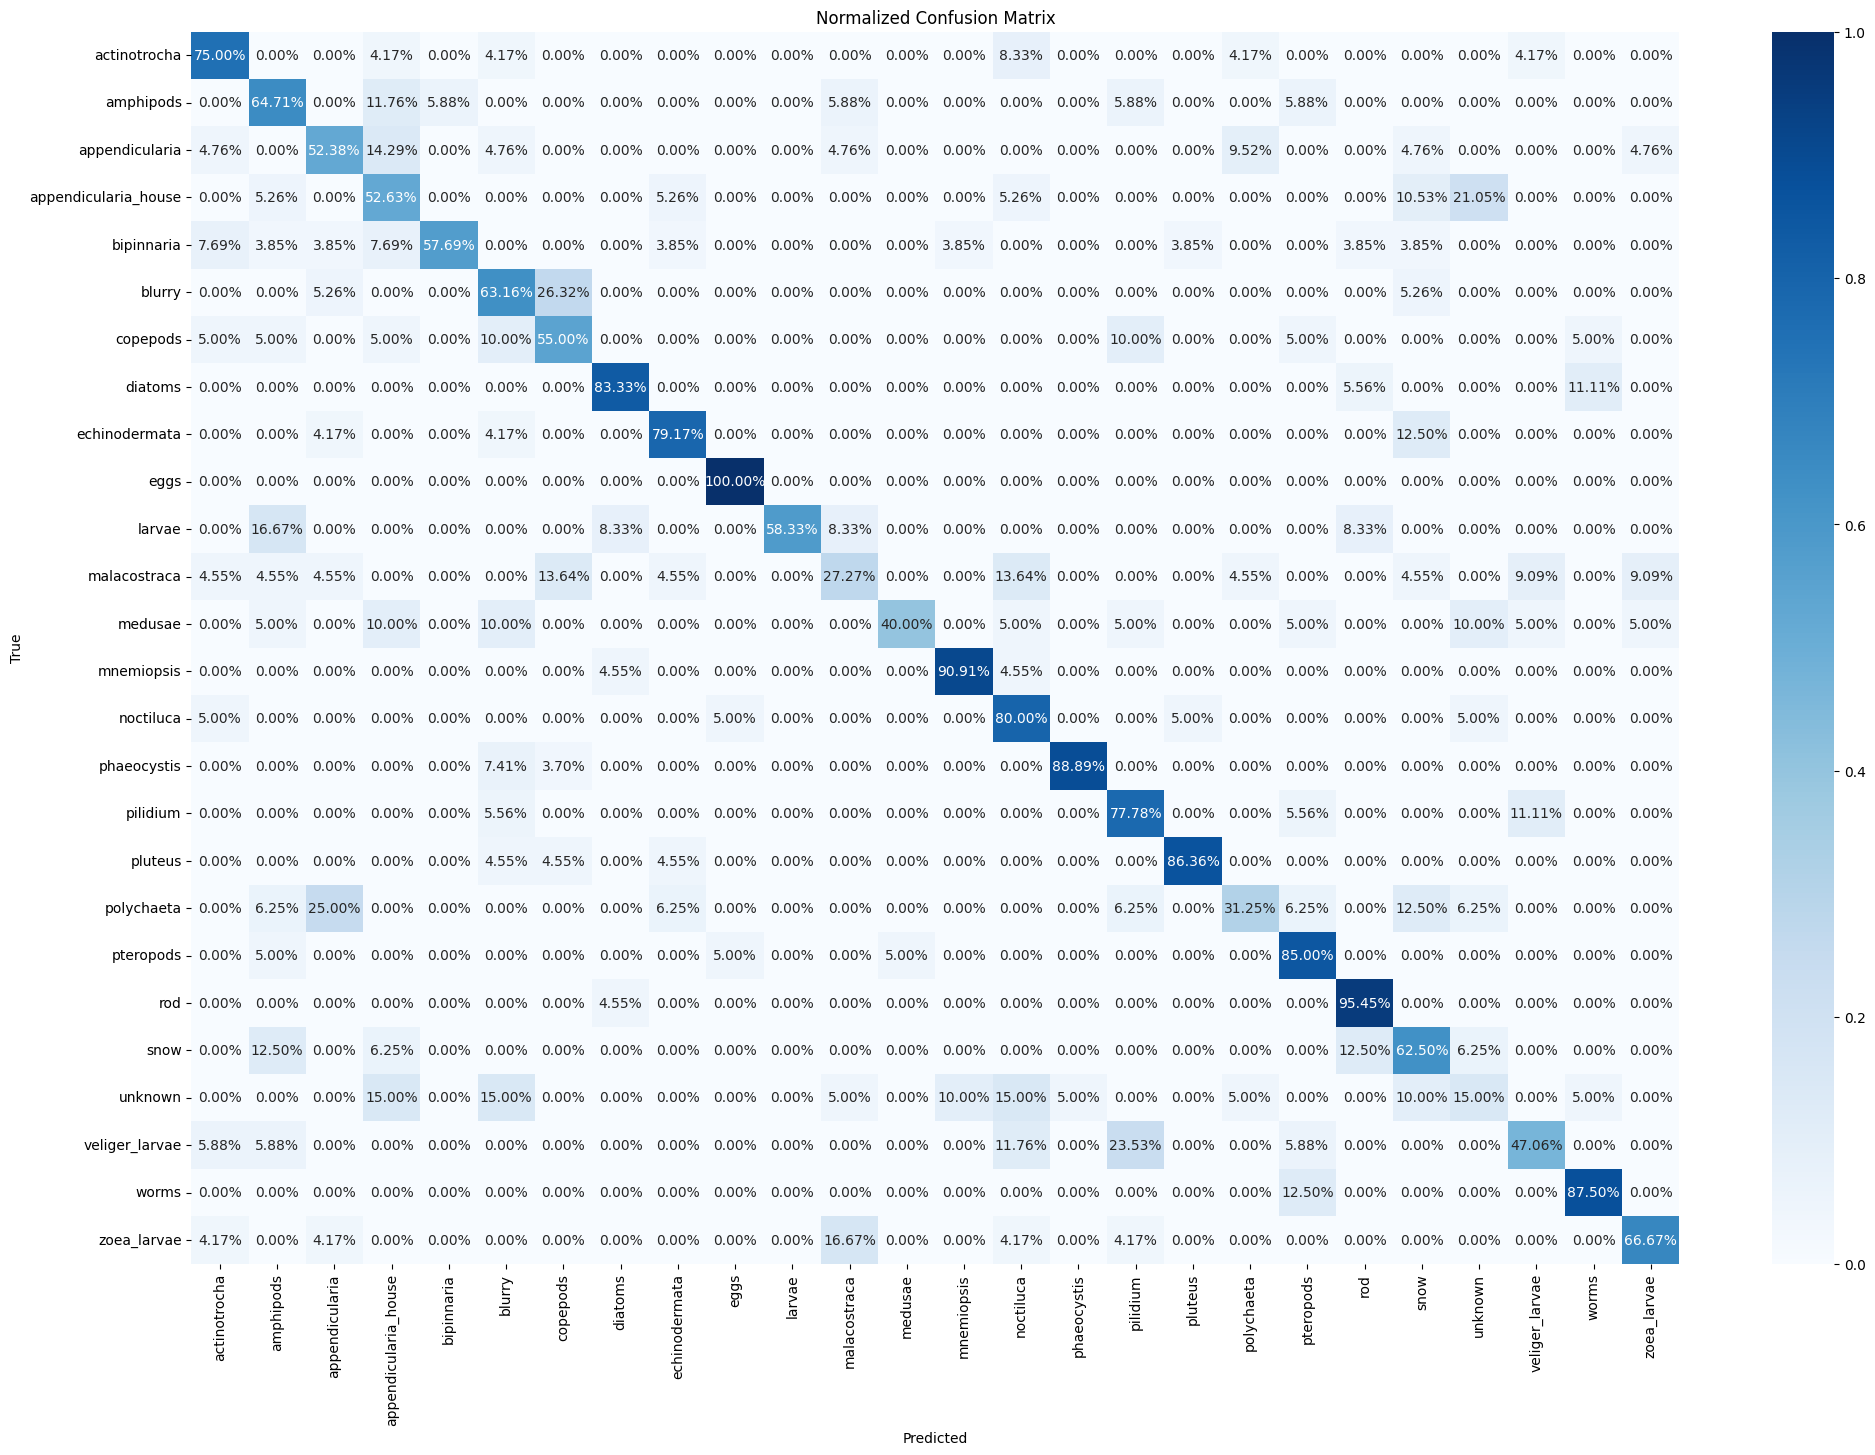

In [29]:
import seaborn as sns

def plot_classwise_accuracy(y_true, y_pred, class_names):
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the normalized confusion matrix
    plt.figure(figsize=(24, 16))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_classwise_accuracy(y_val, y_pred_rf, train_ds.class_names)

---
### Training an SVM Classifier and Plotting the Confusion Matrix


SVM Accuracy: 0.7365384615384616
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        24
           1       0.57      0.71      0.63        17
           2       0.68      0.71      0.70        21
           3       0.45      0.47      0.46        19
           4       0.94      0.62      0.74        26
           5       0.62      0.84      0.71        19
           6       0.70      0.80      0.74        20
           7       0.89      0.89      0.89        18
           8       0.91      0.83      0.87        24
           9       0.78      1.00      0.88        18
          10       0.89      0.67      0.76        12
          11       0.69      0.41      0.51        22
          12       0.61      0.55      0.58        20
          13       0.91      0.91      0.91        22
          14       0.68      0.75      0.71        20
          15       1.00      0.96      0.98        27
          16       0.62      0.83      0.71     

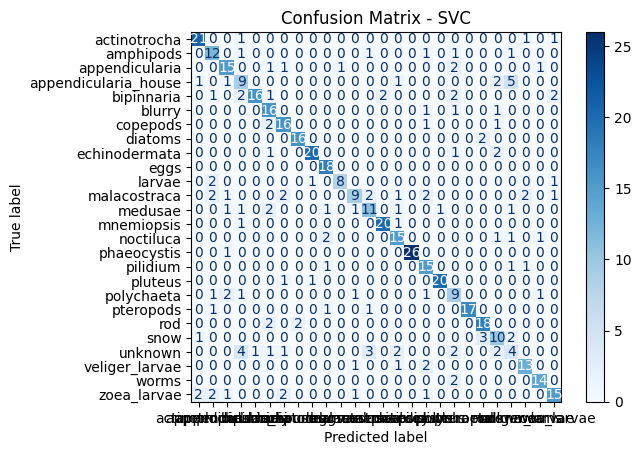

In [17]:
from sklearn.svm import SVC

# Initialize and train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predict on validation set
y_pred_svm = svm_model.predict(X_val)
print("SVM Accuracy:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_val, y_val, class_names):
    # Predict class labels
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

plot_confusion_matrix(svm_model, X_val, y_val, train_ds.class_names)

### Plotting Normalized Class-wise Accuracy for SVM using Confusion Matrix


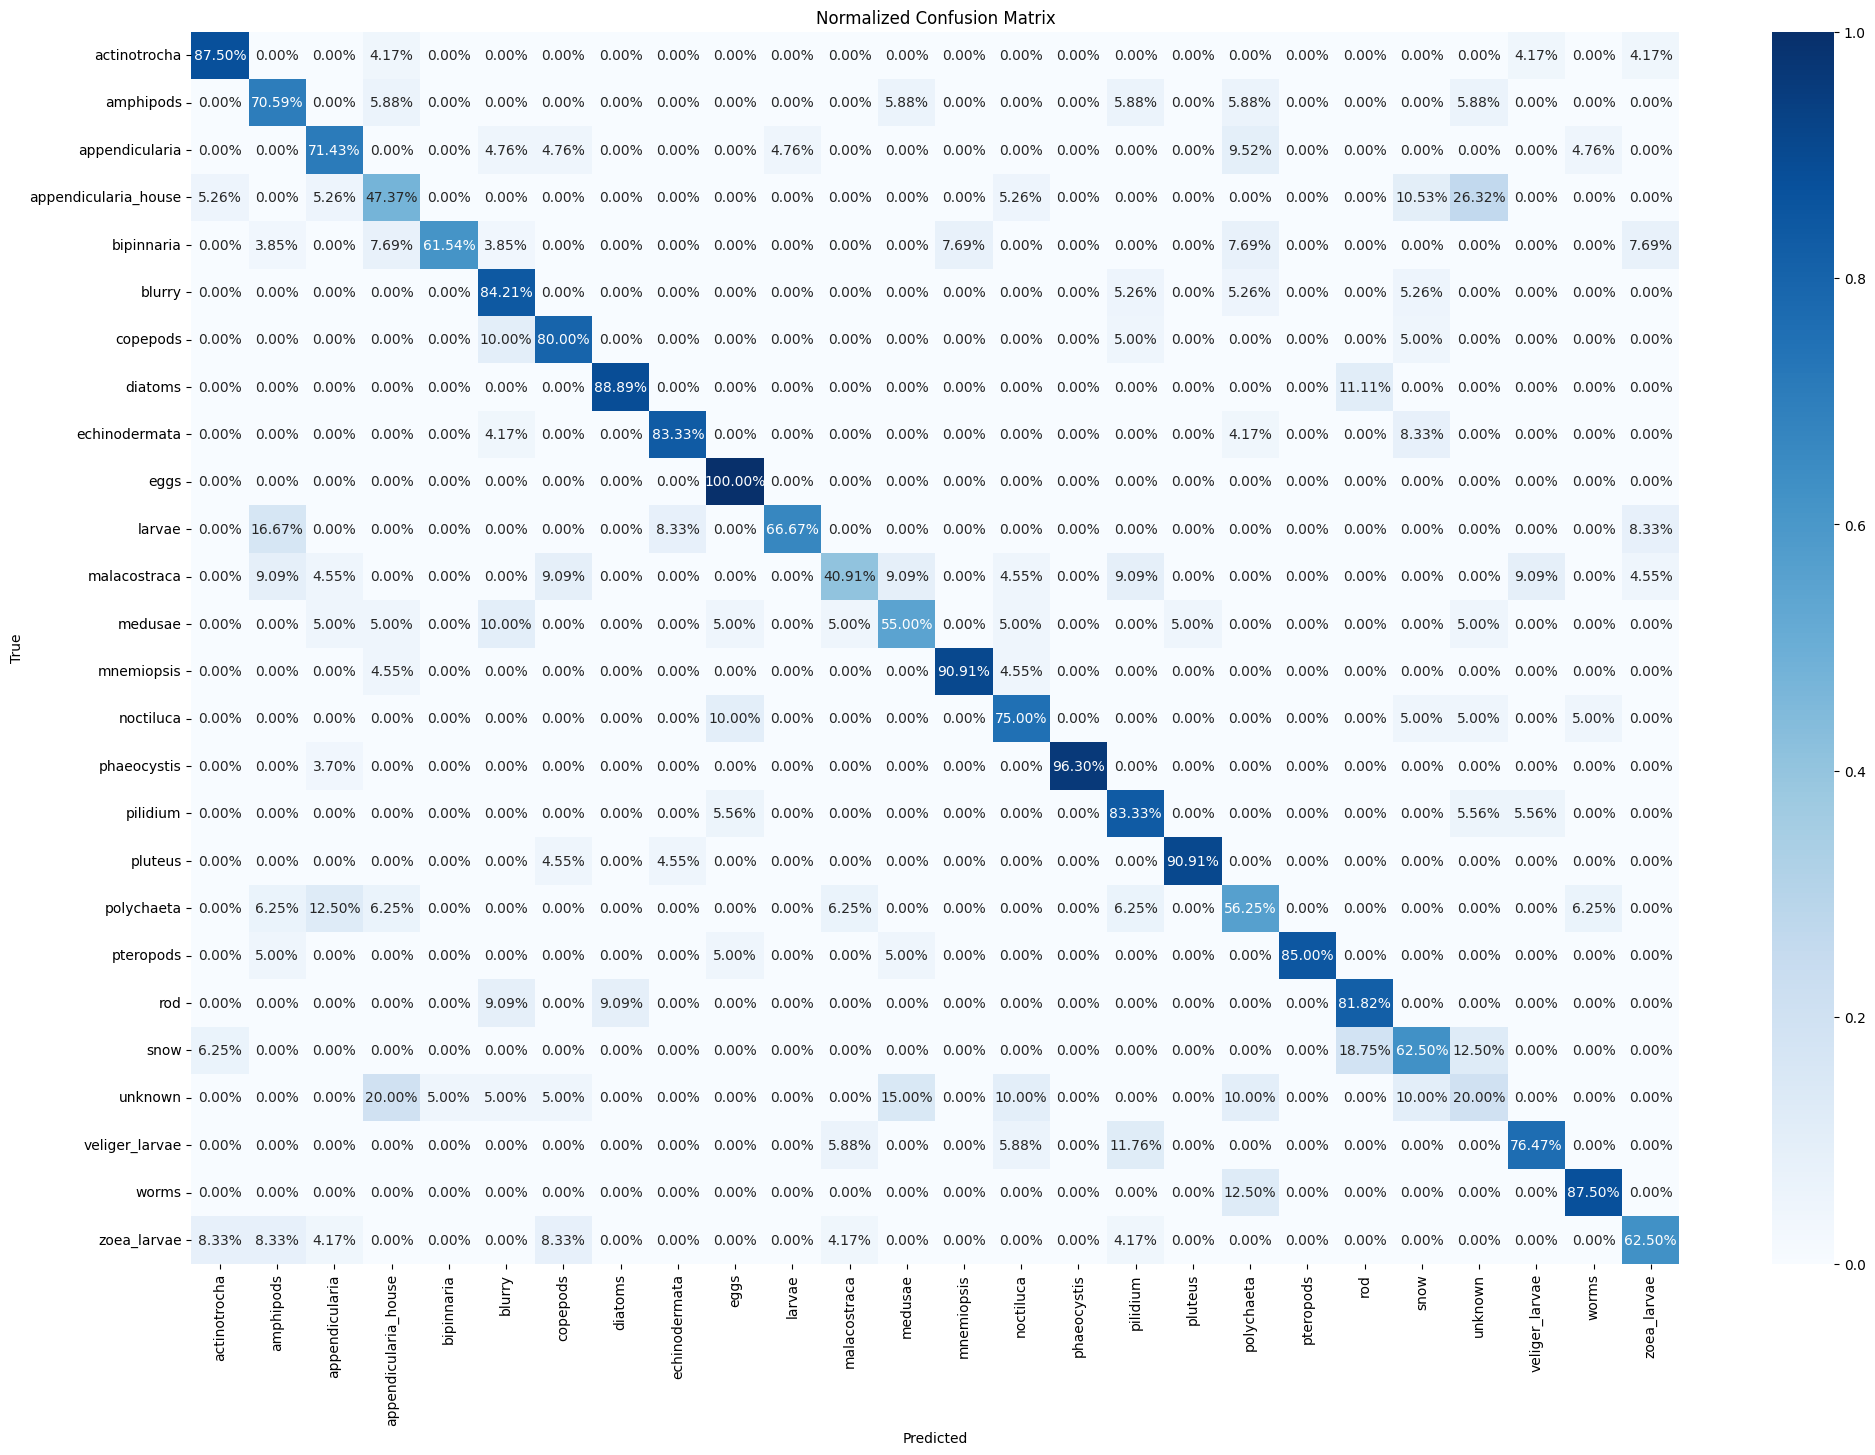

In [28]:
import seaborn as sns

def plot_classwise_accuracy(y_true, y_pred, class_names):
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the normalized confusion matrix
    plt.figure(figsize=(24, 16))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_classwise_accuracy(y_val, y_pred_svm, train_ds.class_names)

---
### Training a KNN Classifier and Plotting the Confusion Matrix


KNN Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.66      0.79      0.72        24
           1       0.39      0.71      0.50        17
           2       0.37      0.62      0.46        21
           3       0.32      0.53      0.40        19
           4       0.82      0.54      0.65        26
           5       0.45      0.68      0.54        19
           6       0.35      0.45      0.39        20
           7       0.76      0.89      0.82        18
           8       0.75      0.62      0.68        24
           9       0.86      1.00      0.92        18
          10       0.88      0.58      0.70        12
          11       0.54      0.32      0.40        22
          12       0.75      0.45      0.56        20
          13       1.00      0.82      0.90        22
          14       0.63      0.85      0.72        20
          15       1.00      0.96      0.98        27
          16       0.54      0.83      0.65        18
        

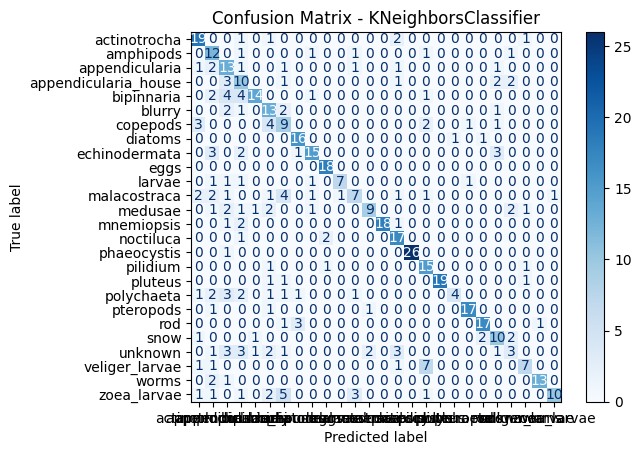

In [23]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train KNN model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Predict on validation set
y_pred_knn = knn_model.predict(X_val)
print("KNN Accuracy:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_val, y_val, class_names):
    # Predict class labels
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

plot_confusion_matrix(knn_model, X_val, y_val, train_ds.class_names)

### Plotting Normalized Class-wise Accuracy for KNN using Confusion Matrix


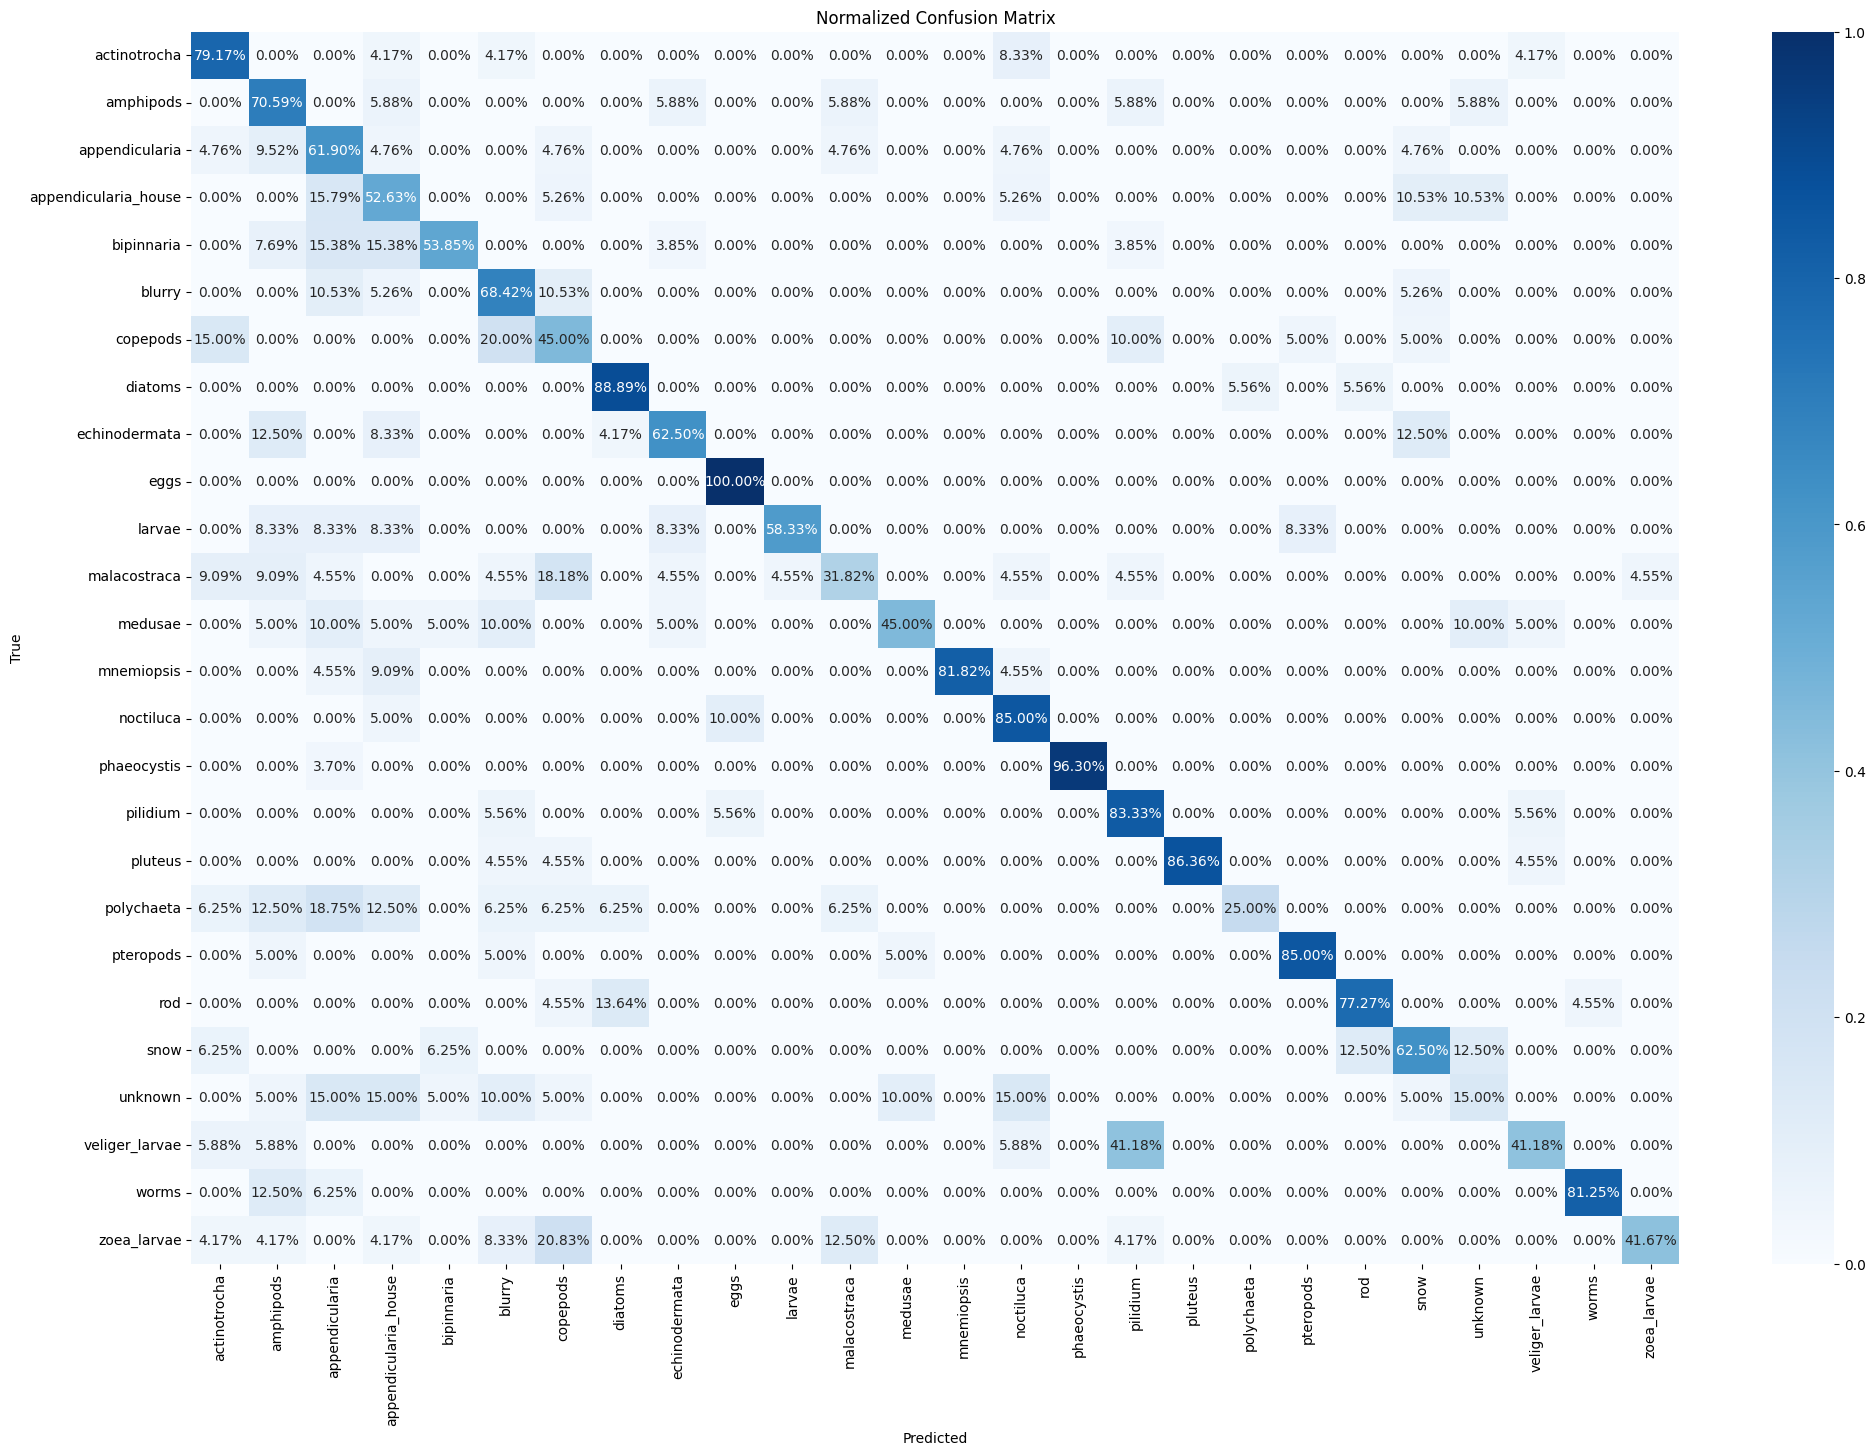

In [26]:
import seaborn as sns

def plot_classwise_accuracy(y_true, y_pred, class_names):
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the normalized confusion matrix
    plt.figure(figsize=(24, 16))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_classwise_accuracy(y_val, y_pred_knn, train_ds.class_names)


---
### Training a Gradient Boosting Classifier and Plotting the Confusion Matrix


Gradient Boosting Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        24
           1       0.62      0.59      0.61        17
           2       0.37      0.48      0.42        21
           3       0.25      0.21      0.23        19
           4       0.93      0.50      0.65        26
           5       0.60      0.63      0.62        19
           6       0.59      0.65      0.62        20
           7       0.80      0.67      0.73        18
           8       0.82      0.58      0.68        24
           9       0.95      1.00      0.97        18
          10       0.88      0.58      0.70        12
          11       0.45      0.41      0.43        22
          12       0.60      0.45      0.51        20
          13       0.88      0.64      0.74        22
          14       0.67      0.80      0.73        20
          15       0.95      0.78      0.86        27
          16       0.48      0.78      0.60    

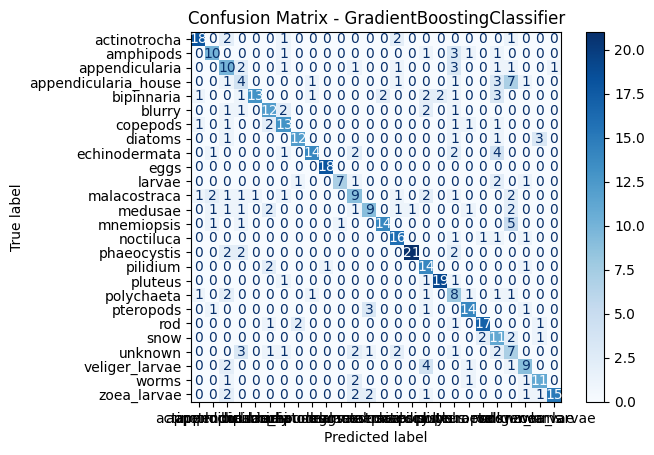

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predict on validation set
y_pred_gb = gb_model.predict(X_val)
print("Gradient Boosting Accuracy:", accuracy_score(y_val, y_pred_gb))
print(classification_report(y_val, y_pred_gb))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_val, y_val, class_names):
    # Predict class labels
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

plot_confusion_matrix(gb_model, X_val, y_val, train_ds.class_names)

### Plotting Normalized Class-wise Accuracy for Gradient Boosting using Confusion Matrix


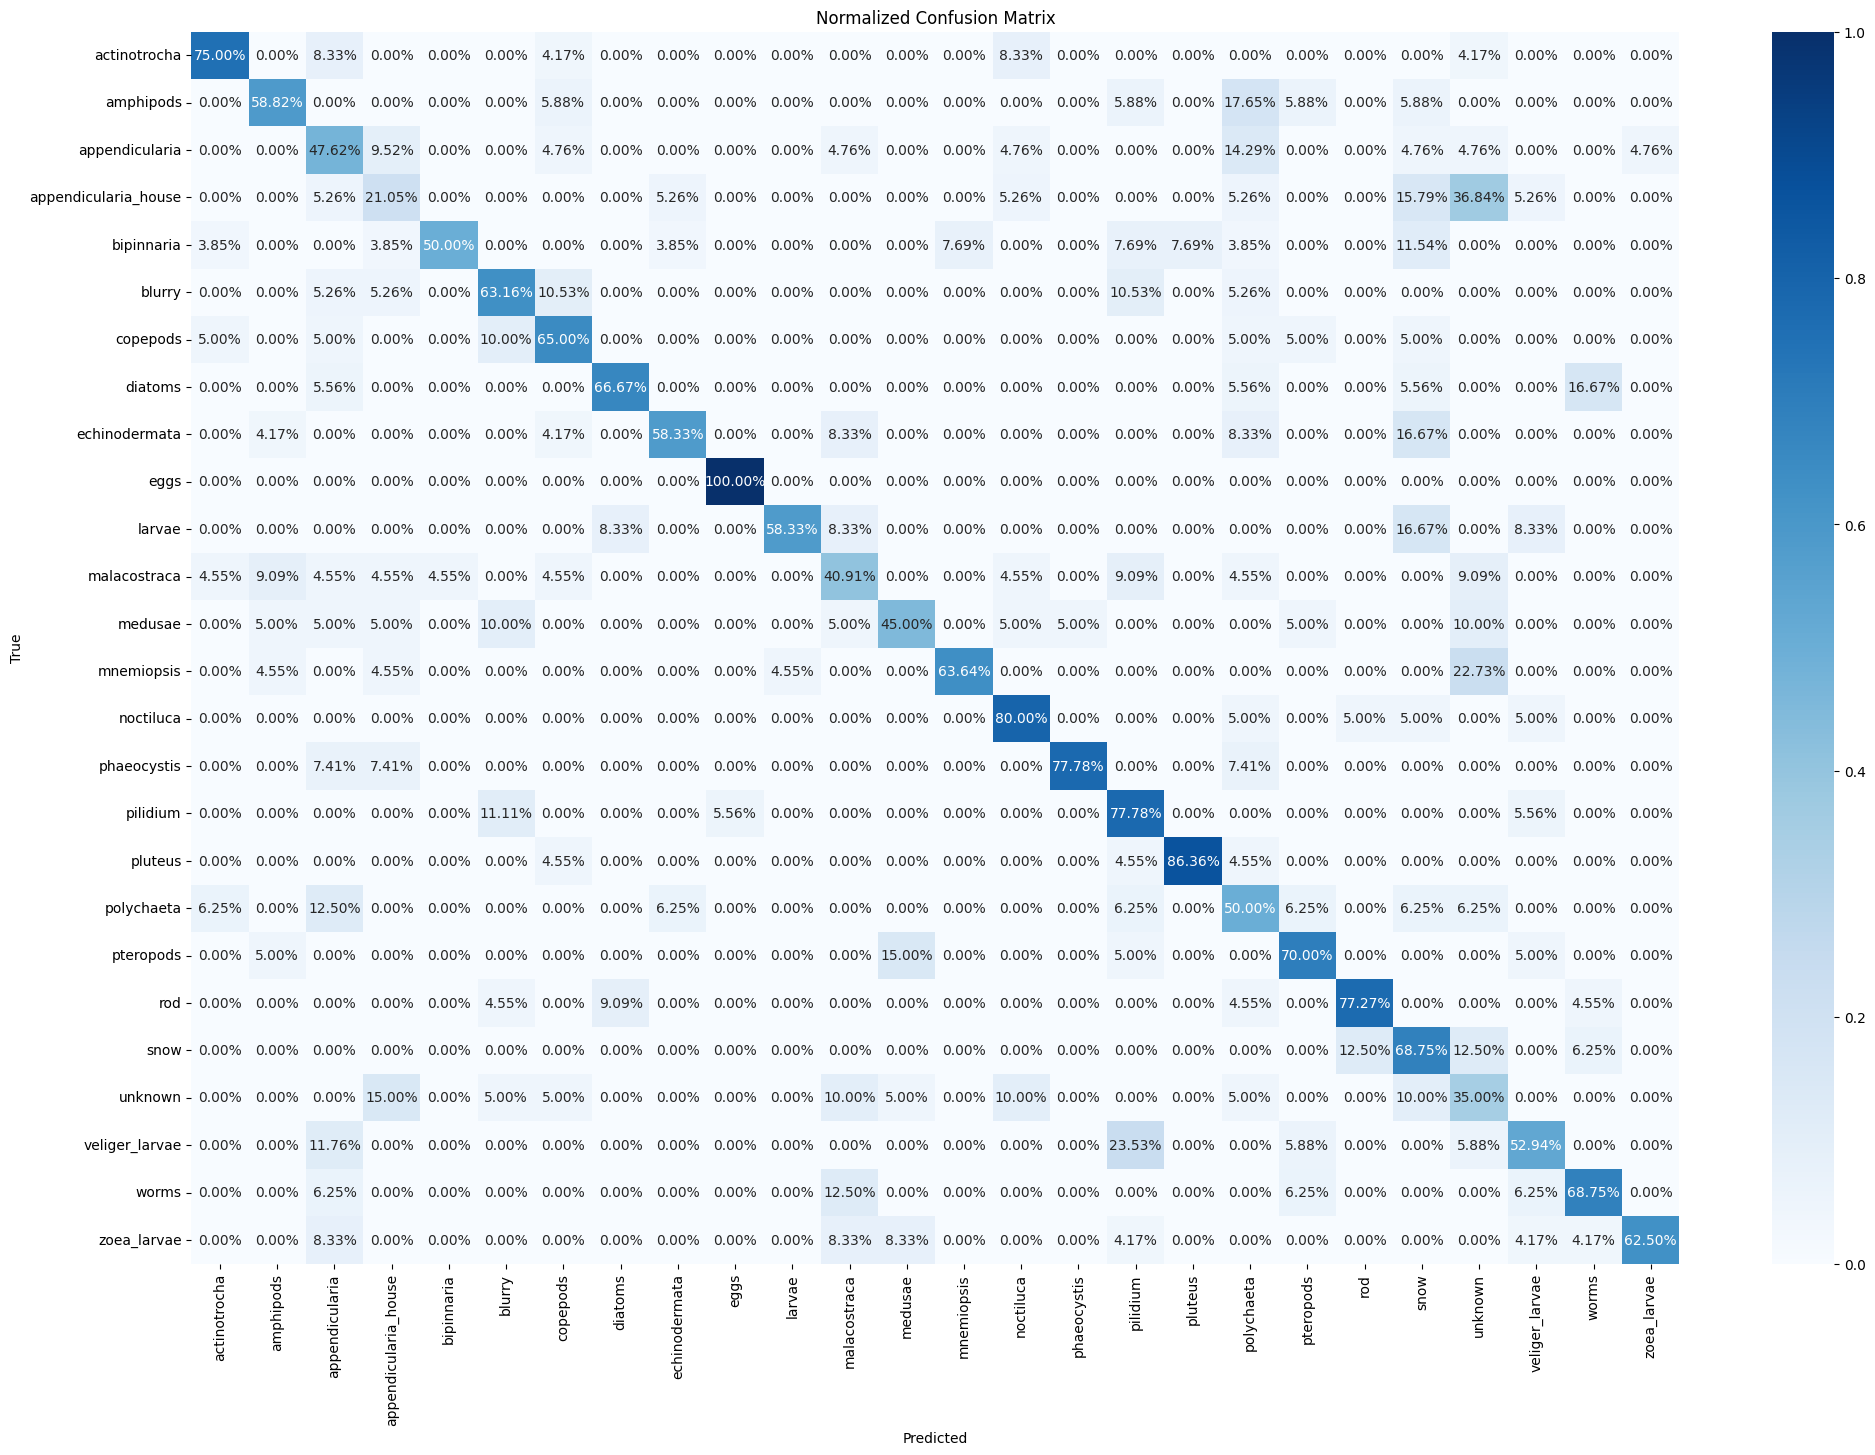

In [25]:
import seaborn as sns

def plot_classwise_accuracy(y_true, y_pred, class_names):
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the confusion matrix to show percentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the normalized confusion matrix
    plt.figure(figsize=(24, 16))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_classwise_accuracy(y_val, y_pred_gb, train_ds.class_names)

---